In [2]:



path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex6-PixelClassificationAndObjectSegmentation/data/"
ct = dicom.dcmread(path + "Training.dcm")
img = ct.pixel_array
print(img.shape)
print(img.dtype)
mask = io.imread(path + "SpleenROI.png")

(512, 512)
int16


In [1]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance


def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap="gray", vmin=-200, vmax=500)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()

/tmp/ipykernel_35479/2650263538.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img, cmap="gray", vmin=1, vmax=15)
/tmp/ipykernel_35479/2650263538.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


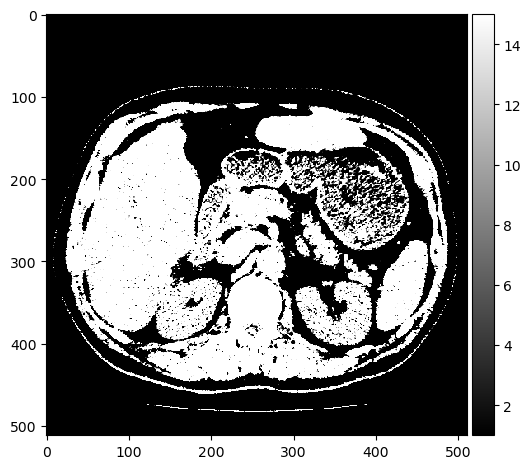

In [3]:
# Exercise 1: Explorative Analysis of one CT scan
io.imshow(img, cmap="gray", vmin=1, vmax=15)
io.show()

spleen_roi = io.imread(path + 'SpleenROI.png')
# convert to boolean image
spleen_mask = spleen_roi > 0
spleen_values = img[spleen_mask]

In [4]:
# Exercise 2

mu_spleen = np.mean(spleen_values)
std_spleen = np.std(spleen_values)    

print(f"Mean: {mu_spleen:.2f}, Std: {std_spleen:.2f}")

Mean: 49.48, Std: 15.00


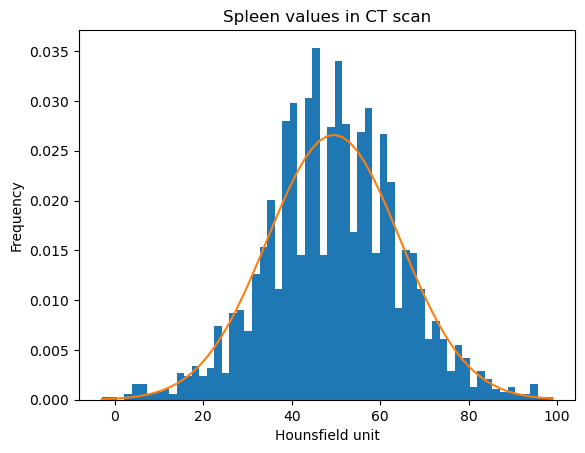

In [5]:
# Exercise 3: Histogram of the pixel values
n, bins, patches = plt.hist(spleen_values, 60, density=1)
pdf_spleen = norm.pdf(bins, mu_spleen, std_spleen)
plt.plot(bins, pdf_spleen)
plt.xlabel('Hounsfield unit')
plt.ylabel('Frequency')
plt.title('Spleen values in CT scan')
plt.show()

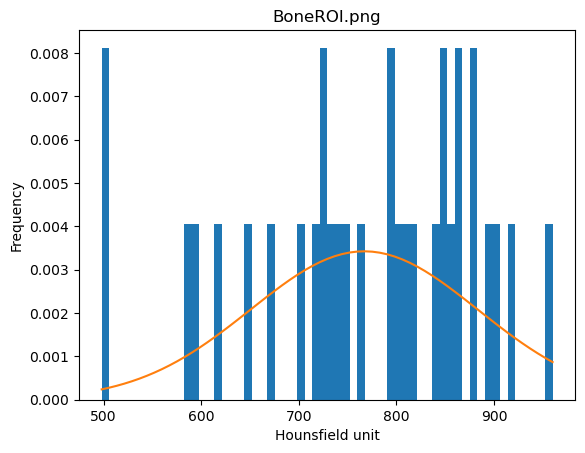

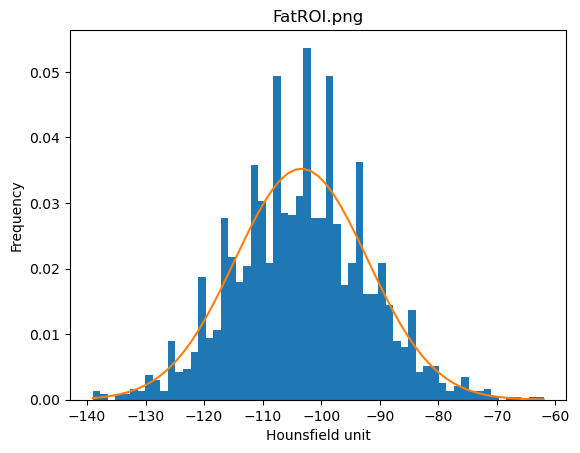

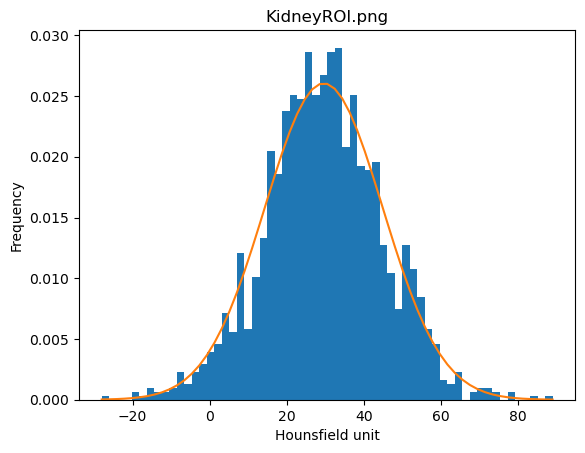

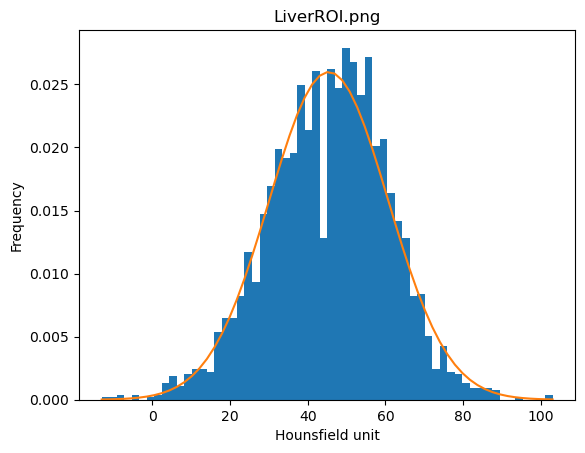

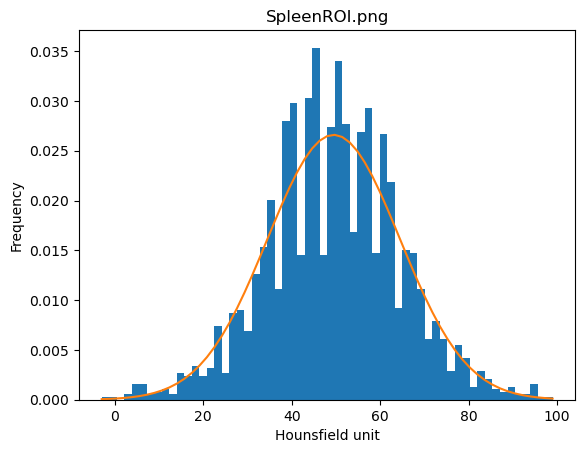

In [6]:
# Exercise 4: Same shit for all the masks

def load_mask(mask_path):
    roi = io.imread(mask_path)
    mask = roi > 0
    return mask

def get_values(img, mask_path):
    mask = load_mask(mask_path)
    values = img[mask]
    return values

def get_gaussian_distributions(values, min_hu = -200, max_hu = 1000):
    hu_range = np.arange(min_hu, max_hu, 1.0)
    mu = np.mean(values)
    std = np.std(values)
    pdf = norm.pdf(hu_range, mu, std)
    return pdf




paths = ['BoneROI.png', 'FatROI.png', 'KidneyROI.png', 'LiverROI.png', 'SpleenROI.png']
values = [get_values(img, path + pathos) for pathos in paths]

for value, name in zip(values, paths):
    n, bins, patches = plt.hist(value, 60, density=1)
    mu = np.mean(value)
    std = np.std(value)
    pdf = norm.pdf(bins, mu, std)
    plt.plot(bins, pdf)
    plt.xlabel('Hounsfield unit')
    plt.ylabel('Frequency')
    plt.title(name)
    plt.show()




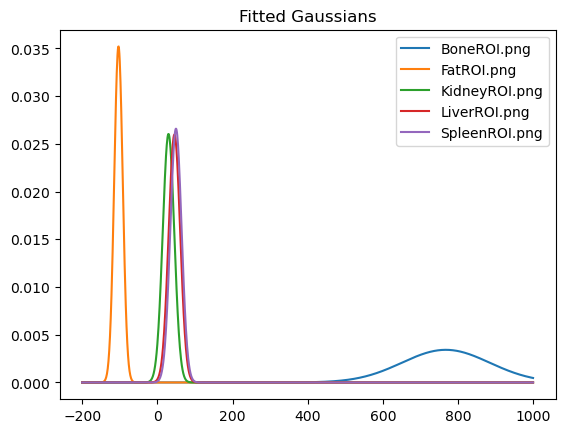

In [7]:
# Exercise 5: 

# Hounsfield unit limits of the plot
min_hu, max_hu = -200, 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdfs = [get_gaussian_distributions(value) for value in values]

for pdf, path in zip(pdfs, paths):
    plt.plot(hu_range, pdf, label=path)

plt.title("Fitted Gaussians")
plt.legend()
plt.show()





In [8]:
# Exercise 6: Defining the classes to classify
# Intensity wise it's best to split into 3 classes: 1: Fat, 2: Spleen, 3: (Bone, Kidney, Liver)

Soft tissue mean: 43.01, fat mean: -103.39, bone mean: 766.94


/tmp/ipykernel_35479/3570906573.py:20: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(fat_img, cmap="gray")


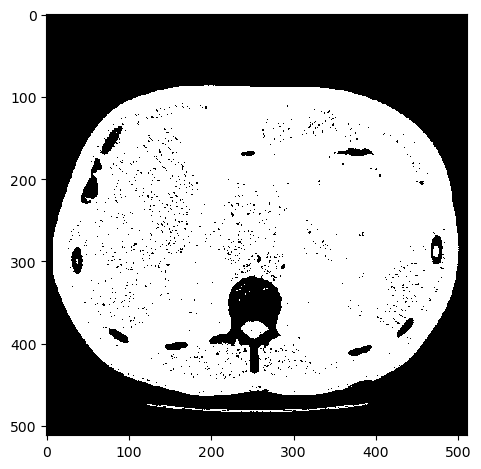

In [9]:
# Minimum Distance Pixel Classification
# Exercise 7: Computing the class ranges defining fat, soft tissue, and bone


fat_mean = np.mean(values[1])
bone_mean = np.mean(values[0])
vals_soft_tissue = np.concatenate(values[-3:])
soft_tissue_mean = np.mean(vals_soft_tissue)


print(f"Soft tissue mean: {soft_tissue_mean:.2f}, fat mean: {fat_mean:.2f}, bone mean: {bone_mean:.2f}")


t_fat_soft = (soft_tissue_mean - fat_mean) / 2
t_soft_bone = (bone_mean - soft_tissue_mean) / 2

t_background = -200
fat_img = (img > t_background) & (img < t_fat_soft)

io.imshow(fat_img, cmap="gray")

/tmp/ipykernel_35479/552956900.py:22: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


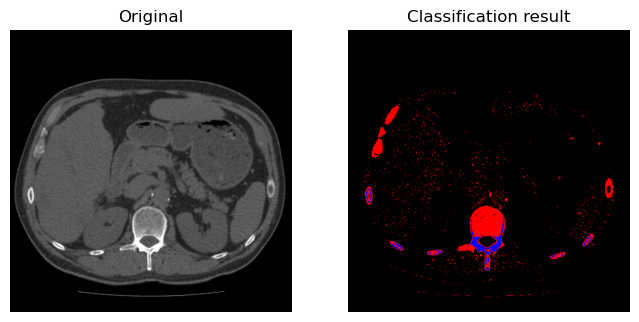

In [10]:
# Exercise 8: Creating class images

t_background = 200
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_img = (img > t_fat_soft) & (img <= t_soft_bone)
bone_img = img > t_soft_bone

label_img = fat_img + 2 * soft_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Classification result')


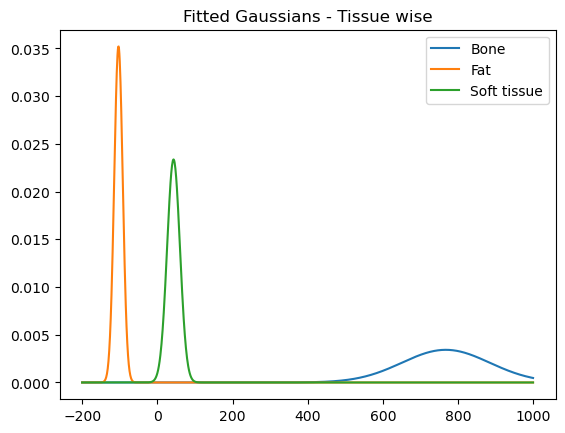

In [11]:
# Parametric Pixel Classification
# Exercise 10:  Plot the fitted Gaussians of the training values and manually find the intersection between the curves.

# Hounsfield unit limits of the plot
min_hu, max_hu = -200, 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
values_3_classes = [values[0], values[1], vals_soft_tissue]
labels_3_classes = ['Bone', 'Fat', 'Soft tissue']

pdfs_3_classes = [get_gaussian_distributions(value) for value in values_3_classes]

for pdf, path in zip(pdfs_3_classes, labels_3_classes):
    plt.plot(hu_range, pdf, label=path)

plt.title("Fitted Gaussians - Tissue wise")
plt.legend()
plt.show()



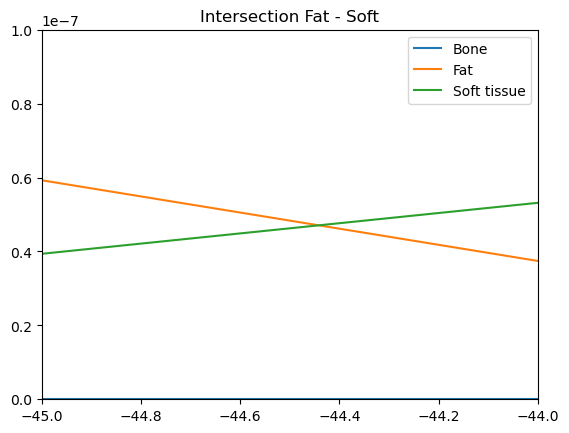

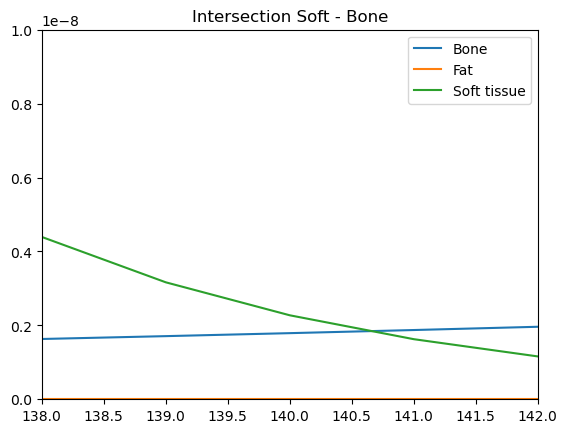

In [12]:
# Manual intersection Fat - Soft
for pdf, path in zip(pdfs_3_classes, labels_3_classes):

    plt.plot(hu_range, pdf, label=path)
plt.title("Intersection Fat - Soft")
plt.xlim(-45, -44)
plt.ylim(0, 1e-7)
plt.legend()
plt.show()

# Manual intersection  Soft - Bone
for pdf, path in zip(pdfs_3_classes, labels_3_classes):
    
    plt.plot(hu_range, pdf, label=path)

plt.title("Intersection Soft - Bone")
plt.xlim(138, 142)
plt.ylim(0, 1e-8)
plt.legend()
plt.show()

In [13]:
# This cell helps you to define an 
# interval for the intersection of the gaussians. 
# Just change the test_value and run the cell again

mu_bone = np.mean(values_3_classes[0])
std_bone = np.std(values_3_classes[0])

mu_fat = np.mean(values_3_classes[1])
std_fat = np.std(values_3_classes[1])

mu_soft = np.mean(values_3_classes[2])
std_soft = np.std(values_3_classes[2])

# Soft vs Bone
test_value = 140
if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_bone, std_bone):
    
    print(f"For value {test_value} the class is soft tissue")
else:
    
    print(f"For value {test_value} the class is bone")

# Soft vs Fat
test_value = -45
if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_fat, std_fat):
    
    print(f"For value {test_value} the class is soft tissue")
else:
    
    print(f"For value {test_value} the class is fat")

For value 140 the class is soft tissue
For value -45 the class is fat
